In [39]:
import numpy as np 
import matplotlib.pyplot as plt


### Covariance Matrix

Covariance matrix C tells you how every pair of features varies together.
Diagonal = variance of each feature (how spread out it is alone).
Off-diagonal = covariance between two features (do they move together?).
Shape is always (n_features × n_features).
Used in PCA — we find eigenvectors of C to get principal components.

In [14]:
#2D data set

np.random.seed(42)
X = np.random.randn(200,2)

X = X @ np.array([[3, 1.5],[1.5, 1]])

#center (subtracting mean from each column)
X_center = X - X.mean(axis=0)

#Calculating covariance matrix using formula (X.T @ X)/(n - 1)
C_manual = (X_center.T @ X_center) / (len(X)-1)

print("Manual Covariance:\n",C_manual)

Manual Covariance:
 [[10.11666861  5.38793473]
 [ 5.38793473  2.91696102]]


In [16]:
#verifying with numpy method
C_numpy = np.cov(X_center.T)
print("NumPy Covariance:\n", C_numpy)
print("Match: ",np.allclose(C_manual,C_numpy))


NumPy Covariance:
 [[10.11666861  5.38793473]
 [ 5.38793473  2.91696102]]
Match:  True


### PCA from scratch

PCA finds the directions of maximum variance in your data.

Step 1: center the data (remove the mean).

Step 2: compute covariance matrix.

Step 3: find eigenvectors. these ARE the principal components.

Step 4: sort by eigenvalue —> bigger = more variance explained.

Step 5: project data onto top k eigenvectors to reduce dimensions.


Why it matters in ML:
- Visualize high-dimensional data in 2D/3D
- Remove noise (low-variance components = noise)
- Speed up training by reducing features
- sklearn.decomposition.PCA uses SVD internally (more stable than eig)

Explained variance ratio: [0.60353137 0.39646863]
Component 1 explains: 60.4%
Original shape: (200, 2)
Reduced shape: (200, 1)


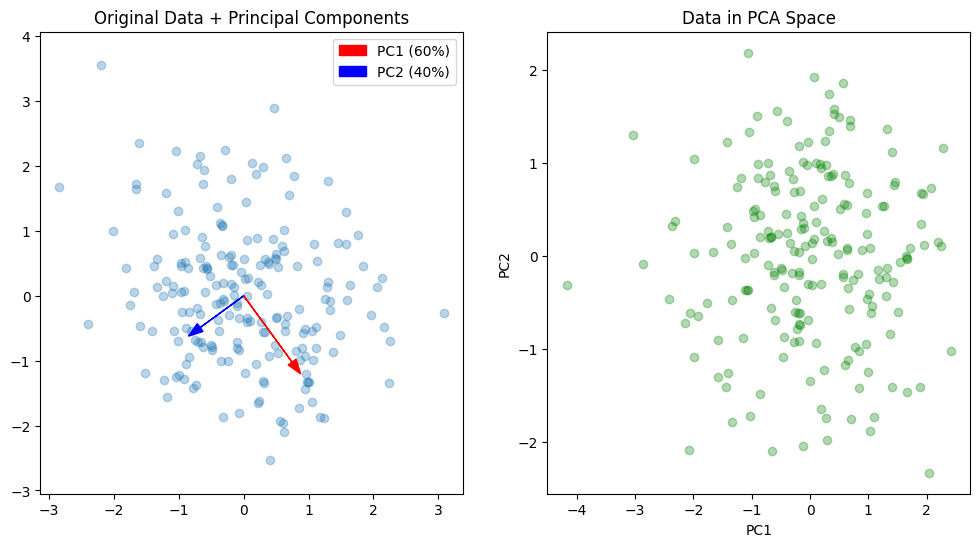


sklearn explained variance: [0.60353137 0.39646863]
Our explained variance:     [0.60353137 0.39646863]
Match: True


In [46]:
np.random.seed(30)

X_raw = np.random.randn(200,2)
X_cen = X_raw - X_raw.mean(axis=0)

#eigendecomposition of covariance matrix
Cov_mat = np.cov(X_cen.T)
eigenvalues, eigenvectors = np.linalg.eig(Cov_mat)

#sorting by eigenvalue - biggest first
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# how much of total variance does each component explain?
explained = eigenvalues / eigenvalues.sum()
print("Explained variance ratio:", explained)
print("Component 1 explains:", f"{explained[0]*100:.1f}%")

#projecting data onto top 1 component (2D->1D)
X_1d = X_cen @ eigenvectors[:, 0:1]
print("Original shape:", X_cen.shape)
print("Reduced shape:", X_1d.shape)

X_2d = X_cen @ eigenvectors

fig, axes = plt.subplots(1,2, figsize=(12,6))

# left: original data + eigenvectors as arrows
axes[0].scatter(X_cen[:, 0], X_cen[:, 1], alpha=0.3)
colors = ['red', 'blue']
for i in range(2):
    vec = eigenvectors[:, i]
    scale = eigenvalues[i]
    axes[0].arrow(0, 0, vec[0]*scale, vec[1]*scale,
                  head_width=0.15, color=colors[i],
                  label=f'PC{i+1} ({explained[i]*100:.0f}%)')
axes[0].set_title('Original Data + Principal Components')
axes[0].legend()
axes[0].axis('equal')

# right: data in PCA space
axes[1].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.3, color='green')
axes[1].set_title('Data in PCA Space')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.show()

# Step 7: verify against sklearn
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X_cen)
print("\nsklearn explained variance:", pca.explained_variance_ratio_)
print("Our explained variance:    ", explained)
print("Match:", np.allclose(np.abs(pca.components_), 
                             np.abs(eigenvectors.T)))

### Linear Regression

Linear regression in matrix form: y = X @ theta
Solving for theta that minimizes ||y - X@theta||²

Normal equation: theta = (X.T @ X)^-1 @ X.T @ y
- Exact answer in one shot
- Slow for large datasets (matrix inverse is O(n³))

Gradient descent: theta = theta - lr * gradient
- Iterative, takes many steps
- Scales to millions of rows
- The foundation of ALL neural network training

Gradient descent: [ 1.4472458   3.02267513 -1.96557566]
True theta:       [ 1.5  3.  -2. ]


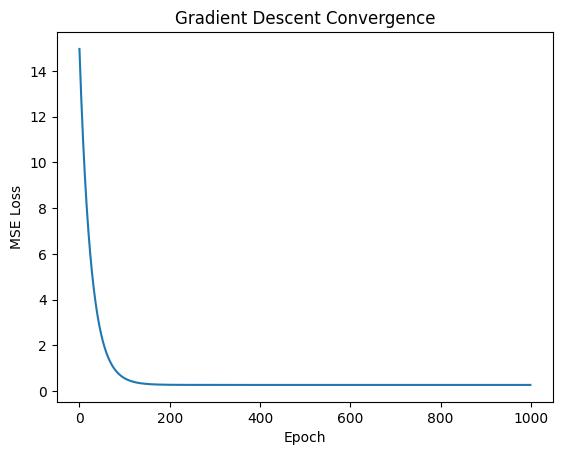

In [54]:
#Generating random data 

np.random.seed(0)
n = 200
X_raw = np.random.randn(n,2)
true_theta = np.array([1.5, 3.0, -2.0]) #bias, w1 and w2

#adding bias column of 1s
X = np.hstack([np.ones((n,1)), X_raw])
y = X @ true_theta + np.random.randn(n) * 0.5 #noise

#Using pure linear algebra
theta_normal = np.linalg.solve(X.T @ X, X.T @ y)

#using gradient descent
theta_gd = np.zeros(3)
lr = 0.01
losses = []

for epoch in range(1000):
    y_pred = X @ theta_gd
    residuals = y_pred - y 
    loss = np.mean(residuals**2)
    losses.append(loss)
    gradient = (2/n) * X.T @ residuals
    theta_gd -= lr * gradient

print("Gradient descent:", theta_gd)
print("True theta:      ", true_theta)

# ploting loss curve
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Gradient Descent Convergence')
plt.show()